In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
import warnings

warnings.filterwarnings('ignore')

In [2]:
df_clean = pd.read_csv('../../dataset/clean/sayur_buah_clean.csv')

print(f"Shape dataset: {df_clean.shape}")
df_clean.head(10)

Shape dataset: (8983, 7)


,nama_item,jenis_item,lokasi_penyimpanan,hari_sejak_pembelian,sisa_hari,label,cara_simpan
0,Jahe,Sayuran Akar,Pembeku,14.0,37.0,Segar,Gunakan wadah khusus freezer untuk menjaga nut...
1,Jahe,Sayuran Akar,Pembeku,60.0,-12.0,Kadaluwarsa,Gunakan wadah khusus freezer untuk menjaga nut...
2,Seledri,Sayuran Akar,Suhu Ruang,60.0,2.0,Segera,Simpan Seledri di tempat gelap dan kering untu...
3,Pisang,Buah Tropis,Pembeku,23.0,7.0,Segar,Simpan Pisang dalam kantong ziplock kedap udar...
4,Cabai Merah,Cabai & Paprika,Pembeku,1.0,4.0,Segar,Simpan Cabai Merah dalam kantong ziplock kedap...
5,Tomat,Buah Tropis,Pendingin,4.0,10.0,Segar,Bungkus Tomat dengan tisu dapur lalu masukkan ...
6,Bawang Putih,Sayuran Akar,Pendingin,25.0,37.0,Segar,Bungkus Bawang Putih dengan tisu dapur lalu ma...
7,Sawi,Sayuran Hijau,Pendingin,2.0,3.0,Segera,Bungkus Sawi dengan tisu dapur lembap dalam wa...
8,Stroberi,Buah Beri,Pembeku,10.0,20.0,Segar,Pastikan Stroberi sudah bersih dan kering sebe...
9,Melon,Buah Tropis,Pembeku,5.0,0.0,Kadaluwarsa,Gunakan wadah khusus freezer untuk menjaga nut...


In [3]:
print(list(df_clean.columns))

['nama_item', 'jenis_item', 'lokasi_penyimpanan', 'hari_sejak_pembelian', 'sisa_hari', 'label', 'cara_simpan']


In [4]:
df_clean.duplicated().sum()

1

In [5]:
for col in df_clean.columns:
    print(f"\nKolom: {col}")
    print(df_clean[col].unique())


Kolom: nama_item
['Jahe' 'Seledri' 'Pisang' 'Cabai Merah' 'Tomat' 'Bawang Putih' 'Sawi'
 'Stroberi' 'Melon' 'Semangka' 'BlueBuah Beri' 'Singkong' 'Bayam' 'Pakcoy'
 'Pepaya' 'Nanas' 'Jeruk Nipis' 'Ubi Jalar' 'Jeruk Bali' 'Kangkung' 'Kiwi'
 'Kunyit' 'Jeruk' 'Paprika' 'Selada' 'Pear' 'Bawang Merah' 'Kentang'
 'Apel' 'RaspBuah Beri' 'Wortel' 'Lemon' 'Anggur' 'Cabai Rawit' 'Brokoli'
 'Mangga' 'Kol' 'Alpukat' 'Anggur Merah (Red Globe)' 'Ubi Cilembu'
 'Kiwi Gold' 'Paprika Kuning' 'Lemon Lokal' 'Lengkuas Muda' 'Apel Gala'
 'Jamur Tiram' 'Pisang Cavendish' 'Selada Butterhead' 'Kencur'
 'Pear Century' 'Tomat Beef' 'Cabai Merah Keriting' 'Singkong Gajah'
 'Tomat Hijau' 'Cabai Hijau Besar' 'Paprika Merah' 'Jeruk Purut'
 'Kol Putih' 'Paprika Hijau' 'Cabai Keriting Hijau' 'Raspberry Merah'
 'Sawi Sendok (Pakcoy)' 'Bawang Bombai Putih' 'Apel Malang (Manalagi)'
 'Stroberi Lokal Ciwidey' 'Bawang Putih Kating' 'Apel Granny Smith'
 'Jeruk Medan' 'Semangka Merah Tanpa Biji' 'Jeruk Siam' 'Apel Fuji'
 'Arb

In [6]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8983 entries, 0 to 8982
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   nama_item             8983 non-null   object 
 1   jenis_item            8983 non-null   object 
 2   lokasi_penyimpanan    8983 non-null   object 
 3   hari_sejak_pembelian  8803 non-null   float64
 4   sisa_hari             8983 non-null   float64
 5   label                 8983 non-null   object 
 6   cara_simpan           8983 non-null   object 
dtypes: float64(2), object(5)
memory usage: 491.4+ KB


In [7]:
df_clean.isna().sum()

nama_item                 0
jenis_item                0
lokasi_penyimpanan        0
hari_sejak_pembelian    180
sisa_hari                 0
label                     0
cara_simpan               0
dtype: int64

In [9]:
df_clean['hari_sejak_pembelian'].describe()

count    8803.000000
mean       19.099966
std        22.473499
min         0.000000
25%         3.000000
50%        10.000000
75%        27.000000
max       125.000000
Name: hari_sejak_pembelian, dtype: float64

In [11]:
df_clean['hari_sejak_pembelian'] = (
    df_clean.groupby('jenis_item')['hari_sejak_pembelian']
    .transform(lambda x: x.fillna(x.median()))
)

In [12]:
df_clean.isna().sum()

nama_item               0
jenis_item              0
lokasi_penyimpanan      0
hari_sejak_pembelian    0
sisa_hari               0
label                   0
cara_simpan             0
dtype: int64

In [13]:
for col in df_clean.columns:
    print(f"\nKolom: {col}")
    print(df_clean[col].unique())


Kolom: nama_item
['Jahe' 'Seledri' 'Pisang' 'Cabai Merah' 'Tomat' 'Bawang Putih' 'Sawi'
 'Stroberi' 'Melon' 'Semangka' 'BlueBuah Beri' 'Singkong' 'Bayam' 'Pakcoy'
 'Pepaya' 'Nanas' 'Jeruk Nipis' 'Ubi Jalar' 'Jeruk Bali' 'Kangkung' 'Kiwi'
 'Kunyit' 'Jeruk' 'Paprika' 'Selada' 'Pear' 'Bawang Merah' 'Kentang'
 'Apel' 'RaspBuah Beri' 'Wortel' 'Lemon' 'Anggur' 'Cabai Rawit' 'Brokoli'
 'Mangga' 'Kol' 'Alpukat' 'Anggur Merah (Red Globe)' 'Ubi Cilembu'
 'Kiwi Gold' 'Paprika Kuning' 'Lemon Lokal' 'Lengkuas Muda' 'Apel Gala'
 'Jamur Tiram' 'Pisang Cavendish' 'Selada Butterhead' 'Kencur'
 'Pear Century' 'Tomat Beef' 'Cabai Merah Keriting' 'Singkong Gajah'
 'Tomat Hijau' 'Cabai Hijau Besar' 'Paprika Merah' 'Jeruk Purut'
 'Kol Putih' 'Paprika Hijau' 'Cabai Keriting Hijau' 'Raspberry Merah'
 'Sawi Sendok (Pakcoy)' 'Bawang Bombai Putih' 'Apel Malang (Manalagi)'
 'Stroberi Lokal Ciwidey' 'Bawang Putih Kating' 'Apel Granny Smith'
 'Jeruk Medan' 'Semangka Merah Tanpa Biji' 'Jeruk Siam' 'Apel Fuji'
 'Arb

Pertanyaan 1: Apa saja jenis item (item_type) yang paling mendominasi inventori kita?


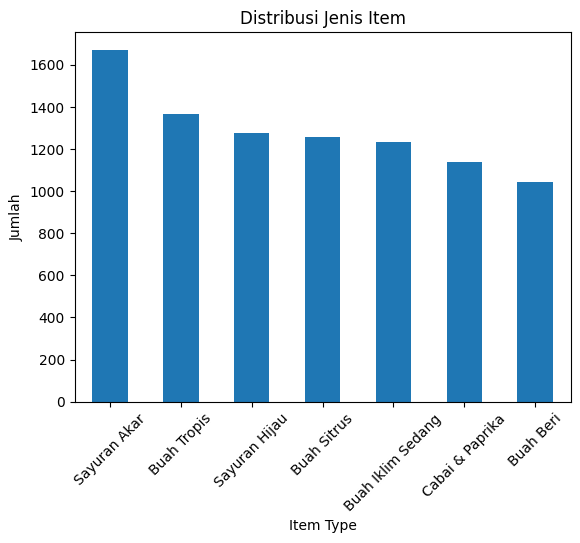

In [14]:
import matplotlib.pyplot as plt

df_clean['jenis_item'].value_counts().plot(kind='bar')

plt.title('Distribusi Jenis Item')
plt.xlabel('Item Type')
plt.ylabel('Jumlah')
plt.xticks(rotation=45)

plt.show()

Pertanyaan 2: Bagaimana distribusi barang berdasarkan lokasi penyimpanan (storage_location)? Apakah ada lokasi yang menampung beban terlalu tinggi?


lokasi_penyimpanan
Pendingin     3461
Pembeku       3075
Suhu Ruang    2447
Name: count, dtype: int64


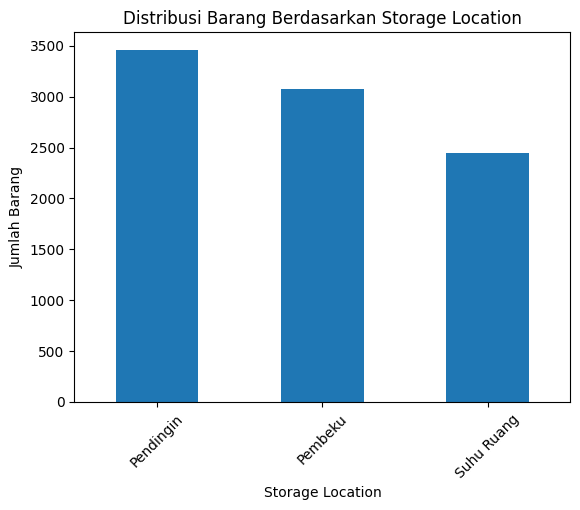

In [15]:
storage_counts = df_clean['lokasi_penyimpanan'].value_counts()
print(storage_counts)
import matplotlib.pyplot as plt

df_clean['lokasi_penyimpanan'].value_counts().plot(kind='bar')

plt.title('Distribusi Barang Berdasarkan Storage Location')
plt.xlabel('Storage Location')
plt.ylabel('Jumlah Barang')
plt.xticks(rotation=45)

plt.show()

In [16]:
storage_counts = df_clean['lokasi_penyimpanan'].value_counts()
avg_storage = storage_counts.mean()
overloaded = storage_counts[storage_counts > avg_storage]
print("Lokasi dengan beban di atas rata-rata:")
print(overloaded)

Lokasi dengan beban di atas rata-rata:
lokasi_penyimpanan
Pendingin    3461
Pembeku      3075
Name: count, dtype: int64


Pertanyaan 3: Berapa banyak item unik (item_name) yang dikelola dalam setiap kategori?


jenis_item
Sayuran Akar         63
Sayuran Hijau        34
Buah Tropis          32
Buah Iklim Sedang    17
Buah Sitrus          13
Cabai & Paprika      13
Buah Beri            10
Name: nama_item, dtype: int64


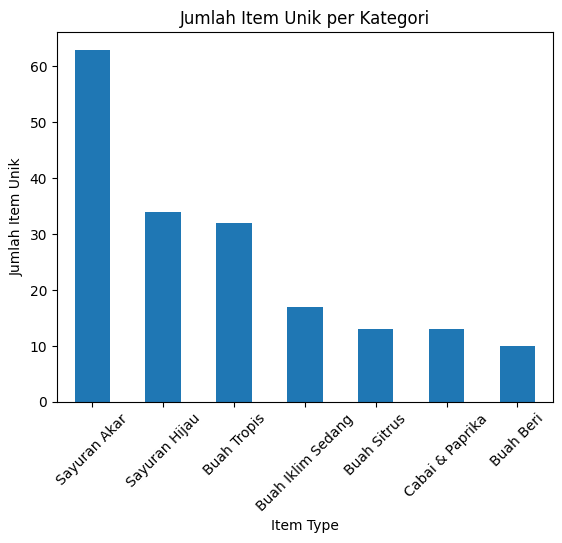

In [17]:
unique_items = (
    df_clean.groupby('jenis_item')['nama_item']
    .nunique()
    .sort_values(ascending=False)
)

print(unique_items)
unique_items.plot(kind='bar')

plt.title('Jumlah Item Unik per Kategori')
plt.xlabel('Item Type')
plt.ylabel('Jumlah Item Unik')
plt.xticks(rotation=45)

plt.show()

Pertanyaan 4: Berapa rata-rata days_since_purchase untuk setiap kategori barang?


jenis_item
Buah Sitrus          27.245028
Cabai & Paprika      24.720175
Sayuran Akar         22.620586
Buah Iklim Sedang    20.034818
Buah Tropis          14.507692
Buah Beri            13.997118
Sayuran Hijau         8.364992
Name: hari_sejak_pembelian, dtype: float64


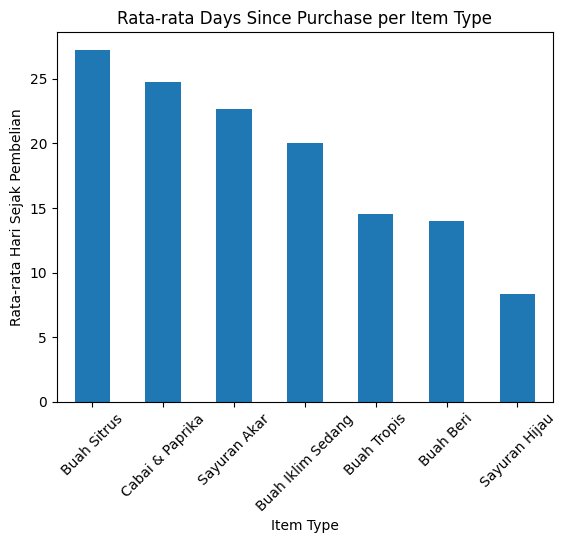

In [18]:
avg_days = (
    df_clean.groupby('jenis_item')['hari_sejak_pembelian']
    .mean()
    .sort_values(ascending=False)
)

print(avg_days)
avg_days.plot(kind='bar')

plt.title('Rata-rata Days Since Purchase per Item Type')
plt.xlabel('Item Type')
plt.ylabel('Rata-rata Hari Sejak Pembelian')
plt.xticks(rotation=45)

plt.show()

Pertanyaan 5: Berdasarkan kolom sisa_hari, berapa persen barang yang masuk dalam kategori kritis (misal: sisa hari < 3 hari)?


3516
Persentase barang kritis: 39.14%


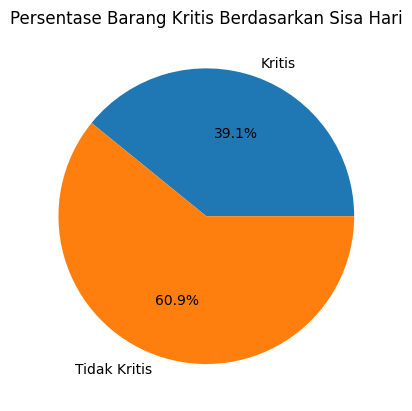

In [19]:
critical_items = df_clean[df_clean['sisa_hari'] < 3]
jumlah_kritis = len(critical_items)
print(jumlah_kritis)
persen_kritis = (len(df_clean[df_clean['sisa_hari'] < 3]) / len(df_clean)) * 100

print(f"Persentase barang kritis: {persen_kritis:.2f}%")
critical_count = len(df_clean[df_clean['sisa_hari'] < 3])
non_critical_count = len(df_clean) - critical_count

plt.pie(
    [critical_count, non_critical_count],
    labels=['Kritis', 'Tidak Kritis'],
    autopct='%1.1f%%'
)
plt.title('Persentase Barang Kritis Berdasarkan Sisa Hari')
plt.show()

Pertanyaan 6: Apakah lokasi penyimpanan tertentu berkorelasi dengan sisa hari yang lebih pendek? (Contoh: Apakah barang di lokasi X lebih cepat basi/habis dibanding lokasi Y?)


lokasi_penyimpanan
Suhu Ruang     4.123376
Pendingin      6.891332
Pembeku       20.409106
Name: sisa_hari, dtype: float64


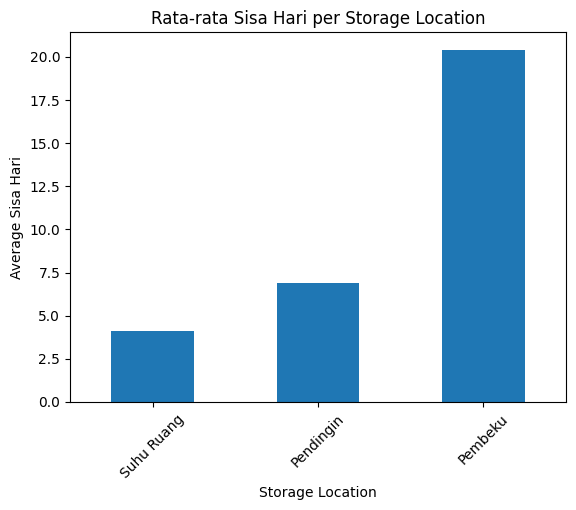

In [20]:
avg_sisa_storage = (
    df_clean.groupby('lokasi_penyimpanan')['sisa_hari']
    .mean()
    .sort_values()
)

print(avg_sisa_storage)

avg_sisa_storage.plot(kind='bar')
plt.title('Rata-rata Sisa Hari per Storage Location')
plt.xlabel('Storage Location')
plt.ylabel('Average Sisa Hari')
plt.xticks(rotation=45)
plt.show()

Pertanyaan 7: Kombinasi item_type dan storage_location mana yang paling berisiko menyebabkan food waste?


           jenis_item lokasi_penyimpanan  jumlah_kritis
19      Sayuran Hijau          Pendingin            384
1           Buah Beri          Pendingin            326
17       Sayuran Akar         Suhu Ruang            263
11        Buah Tropis         Suhu Ruang            236
5   Buah Iklim Sedang         Suhu Ruang            192
14    Cabai & Paprika         Suhu Ruang            184
10        Buah Tropis          Pendingin            181
9         Buah Tropis            Pembeku            172
20      Sayuran Hijau         Suhu Ruang            162
16       Sayuran Akar          Pendingin            142
13    Cabai & Paprika          Pendingin            134
6         Buah Sitrus            Pembeku            130
4   Buah Iklim Sedang          Pendingin            128
8         Buah Sitrus         Suhu Ruang            123
15       Sayuran Akar            Pembeku            123
3   Buah Iklim Sedang            Pembeku            122
7         Buah Sitrus          Pendingin        

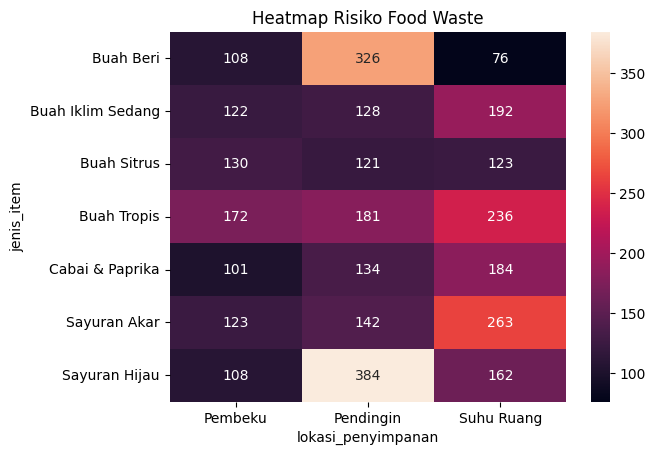

In [21]:
critical_df = df_clean[df_clean['sisa_hari'] < 3]
risk_combo = (
    critical_df
    .groupby(['jenis_item', 'lokasi_penyimpanan'])
    .size()
    .reset_index(name='jumlah_kritis')
    .sort_values(by='jumlah_kritis', ascending=False)
)

print(risk_combo)
heatmap_data = pd.pivot_table(
    critical_df,
    values='sisa_hari',
    index='jenis_item',
    columns='lokasi_penyimpanan',
    aggfunc='count'
)

sns.heatmap(heatmap_data, annot=True, fmt='.0f')

plt.title('Heatmap Risiko Food Waste')
plt.show()

Pertanyaan 8: Apakah terdapat kategori makanan yang memiliki rata-rata sisa_hari paling rendah?


jenis_item
Sayuran Hijau         4.511852
Buah Tropis           7.975165
Buah Beri             8.647454
Buah Iklim Sedang    11.906964
Sayuran Akar         12.614901
Cabai & Paprika      13.839825
Buah Sitrus          15.513604
Name: sisa_hari, dtype: float64


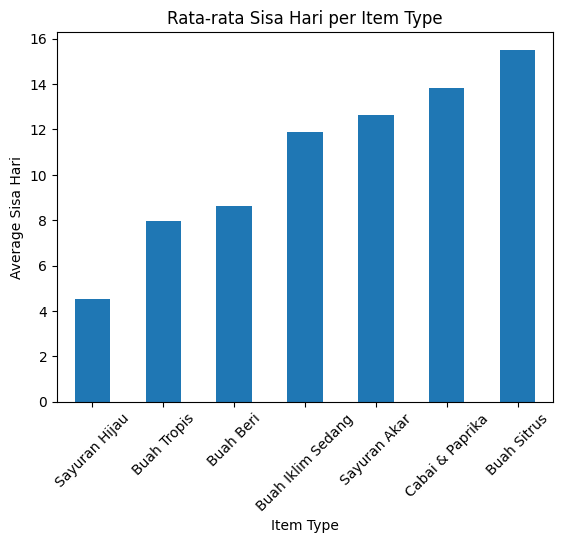

In [22]:
avg_sisa = (
    df_clean.groupby('jenis_item')['sisa_hari']
    .mean()
    .sort_values()
)
print(avg_sisa)

avg_sisa.plot(kind='bar')

plt.title('Rata-rata Sisa Hari per Item Type')
plt.xlabel('Item Type')
plt.ylabel('Average Sisa Hari')
plt.xticks(rotation=45)

plt.show()

Pertanyaan 9: Kategori makanan mana yang paling sering masuk kondisi kritis (sisa_hari < 3)?


jenis_item
Sayuran Hijau        654
Buah Tropis          589
Sayuran Akar         528
Buah Beri            510
Buah Iklim Sedang    442
Cabai & Paprika      419
Buah Sitrus          374
Name: count, dtype: int64


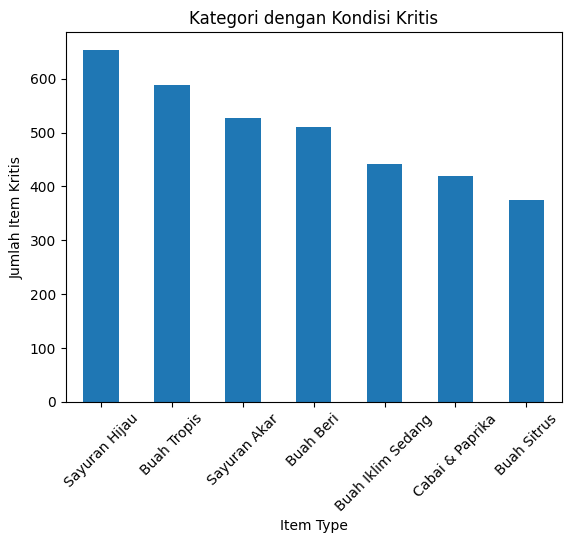

In [23]:
critical_items = df_clean[df_clean['sisa_hari'] < 3]

critical_by_type = (
    critical_items['jenis_item']
    .value_counts()
)

print(critical_by_type)
critical_by_type.plot(kind='bar')

plt.title('Kategori dengan Kondisi Kritis')
plt.xlabel('Item Type')
plt.ylabel('Jumlah Item Kritis')
plt.xticks(rotation=45)

plt.show()

Pertanyaan 10: Apakah terdapat item tertentu yang berulang kali memiliki sisa_hari rendah?


nama_item
Stroberi Korea            74
Stroberi Lokal Ciwidey    66
Blueberry Impor           65
Mulberry                  63
Arbei                     59
Raspberry Merah           58
Blackberry                58
Jeruk Bali                52
Jeruk Nipis               44
Cabai Rawit Merah         39
Name: count, dtype: int64


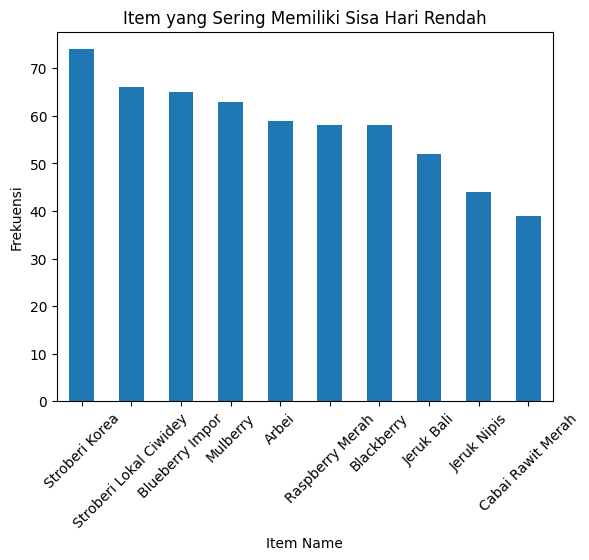

In [24]:
low_sisa_items = df_clean[df_clean['sisa_hari'] < 3]
repeat_risk_items = (
    low_sisa_items['nama_item']
    .value_counts()
    .head(10)
)
print(repeat_risk_items)
repeat_risk_items.plot(kind='bar')

plt.title('Item yang Sering Memiliki Sisa Hari Rendah')
plt.xlabel('Item Name')
plt.ylabel('Frekuensi')
plt.xticks(rotation=45)

plt.show()

Pertanyaan 11: Lokasi penyimpanan mana yang paling efektif menjaga makanan tetap awet?


lokasi_penyimpanan
Pembeku       20.409106
Pendingin      6.891332
Suhu Ruang     4.123376
Name: sisa_hari, dtype: float64


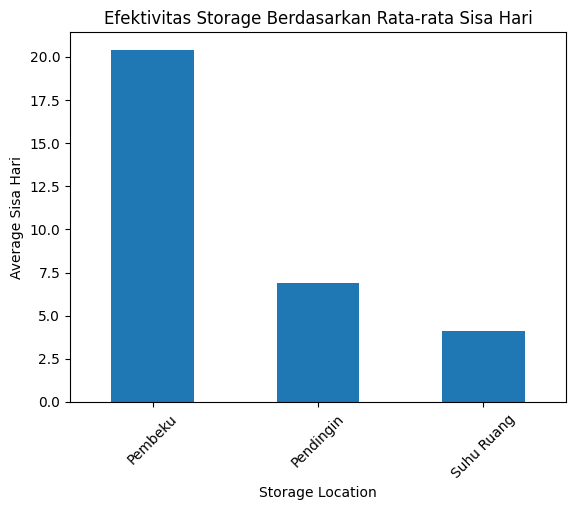

In [25]:
storage_effectiveness = (
    df_clean.groupby('lokasi_penyimpanan')['sisa_hari']
    .mean()
    .sort_values(ascending=False)
)

print(storage_effectiveness)
storage_effectiveness.plot(kind='bar')

plt.title('Efektivitas Storage Berdasarkan Rata-rata Sisa Hari')
plt.xlabel('Storage Location')
plt.ylabel('Average Sisa Hari')
plt.xticks(rotation=45)

plt.show()

Pertanyaan 12: Apakah ada kategori makanan yang disimpan pada lokasi yang kurang sesuai?


lokasi_penyimpanan  Pembeku  Pendingin  Suhu Ruang
jenis_item                                        
Buah Beri               371        583          87
Buah Iklim Sedang       477        400         358
Buah Sitrus             483        415         359
Buah Tropis             572        420         373
Cabai & Paprika         407        376         357
Sayuran Akar            447        515         709
Sayuran Hijau           318        752         204
Empty DataFrame
Columns: [nama_item, jenis_item, lokasi_penyimpanan, hari_sejak_pembelian, sisa_hari, label, cara_simpan]
Index: []


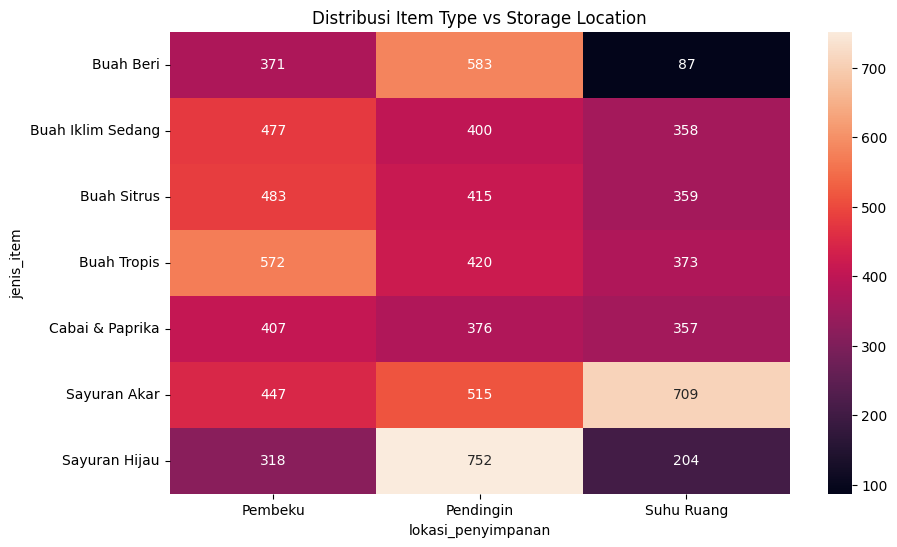

In [26]:
storage_item_table = pd.crosstab(
    df_clean['jenis_item'],
    df_clean['lokasi_penyimpanan']
)

print(storage_item_table)
wrong_storage = df_clean[
    (
        (df_clean['jenis_item'] == 'Dairy') &
        (df_clean['lokasi_penyimpanan'] == 'Room Temperature')
    )
    |
    (
        (df_clean['jenis_item'] == 'Frozen') &
        (df_clean['lokasi_penyimpanan'] == 'Refrigerator')
    )
]

print(wrong_storage)
storage_item_table = pd.crosstab(
    df_clean['jenis_item'],
    df_clean['lokasi_penyimpanan']
)

plt.figure(figsize=(10,6))

sns.heatmap(storage_item_table, annot=True, fmt='d')

plt.title('Distribusi Item Type vs Storage Location')

plt.show()